# Phase 1 – Ingest & Network Matching
Clean version for demo.

This notebook:
- Loads SNOTEL (Idaho)
- Loads Synoptic (Idaho)
- Builds `stations_all.csv`
- Computes SNOTEL ↔ Synoptic spatial match
- Map of synoptic and SNOTEL in and out


In [8]:
# Core imports
import os
import requests
import pandas as pd
import numpy as np
from datetime import datetime
from math import radians, cos, sin, asin, sqrt
from pathlib import Path
import re
from typing import Optional, List

import os
SYNOPTIC_TOKEN = os.getenv("SYNOPTIC_TOKEN")
OUT_DIR = 'out'
Path(OUT_DIR).mkdir(exist_ok=True)

MAX_DIST_M = 200


SNOTEL_ID_URL = "https://wcc.sc.egov.usda.gov/nwcc/sntlsites.jsp?state=ID"
SYNOPTIC_METADATA_URL = "https://api.synopticdata.com/v2/stations/metadata"

SYNOPTIC_TOKEN = os.getenv("SYNOPTIC_TOKEN", "").strip()

os.makedirs(OUT_DIR, exist_ok=True)


In [9]:
#helpers
def clean_text(s) -> str:
    if s is None:
        return ""
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def norm_name(s: str) -> str:
    s = clean_text(s).lower()
    s = re.sub(r"[^a-z0-9 ]+", "", s)
    s = re.sub(r"\b(station|stn|site)\b", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def haversine_m(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    R = 6371000.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dl/2)**2
    return 2*R*math.atan2(math.sqrt(a), math.sqrt(1-a))

def fetch_snotel_idaho(timeout: int = 30) -> pd.DataFrame:
    """Fetch official SNOTEL Idaho station list (NRCS/WCC HTML table) and normalize."""
    print(f"[SNOTEL] Fetching: {SNOTEL_ID_URL}")
    tables = pd.read_html(SNOTEL_ID_URL)
    if not tables:
        raise RuntimeError("No tables found on SNOTEL page. Page layout may have changed.")

    df = max(tables, key=lambda t: t.shape[0]).copy()
    df.columns = [clean_text(c) for c in df.columns]

    # The WCC table commonly uses: site_name, ts, start, lat, lon, elev, county, huc
    # We'll prefer the known WCC column names, but keep a fallback picker.
    cols = {c.lower(): c for c in df.columns}

    def pick(*cands) -> Optional[str]:
        for cand in cands:
            cand = cand.lower()
            if cand in cols:
                return cols[cand]
        # fallback: contains match
        for c in df.columns:
            cl = c.lower()
            for cand in cands:
                if cand.lower() in cl:
                    return c
        return None

    c_name = pick("site_name", "site name", "name")
    c_lat  = pick("lat", "latitude")
    c_lon  = pick("lon", "longitude")
    c_elev = pick("elev", "elevation")

    out = pd.DataFrame({
        "source": "SNOTEL",
        "station_name": df[c_name].astype(str) if c_name else None,
        "latitude": pd.to_numeric(df[c_lat], errors="coerce") if c_lat else None,
        "longitude": pd.to_numeric(df[c_lon], errors="coerce") if c_lon else None,
        "elevation_m": pd.to_numeric(df[c_elev], errors="coerce") if c_elev else None,
    })

    # Extract numeric site_id from "Name (1234)" pattern, then clean the name
    out["station_name"] = out["station_name"].map(clean_text)
    out["source_station_id"] = out["station_name"].str.extract(r"\((\d+)\)").iloc[:, 0]
    out["station_name"] = out["station_name"].str.replace(r"\s*\(\d+\)\s*", "", regex=True).str.strip()

    out["name_norm"] = out["station_name"].map(norm_name)
    out["station_uid"] = "SNOTEL:" + out["source_station_id"].astype(str)

    out = out.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
    print(f"[SNOTEL] Stations loaded: {len(out)}")
    return out
def fetch_synoptic_idaho(token: str, timeout: int = 60) -> pd.DataFrame:
    """Fetch Synoptic station metadata for Idaho (active)."""
    if not token:
        raise ValueError("Synoptic token missing. Set env var SYNOPTIC_TOKEN.")

    params = {
        "state": "ID",
        "status": "active",
        "token": token,
        # IMPORTANT: avoid 'fields=' here unless you're sure of allowed values for your account/version.
        # We'll pull full station objects and then extract the columns we need.
    }

    print("[Synoptic] Requesting metadata for Idaho (active)")
    r = requests.get(SYNOPTIC_METADATA_URL, params=params, timeout=timeout)
    r.raise_for_status()
    js = r.json()

    if "STATION" not in js:
        raise RuntimeError(f"Unexpected Synoptic response keys: {list(js.keys())} | SUMMARY={js.get('SUMMARY')}")

    rows = []
    for s in js["STATION"]:
        stid = clean_text(s.get("STID") or s.get("stid") or "")
        name = clean_text(s.get("NAME") or s.get("name") or "")
        lat  = s.get("LATITUDE") or s.get("latitude")
        lon  = s.get("LONGITUDE") or s.get("longitude")
        elev = s.get("ELEVATION") or s.get("elevation")

        # Network fields
        mnet_id = s.get("MNET_ID") or s.get("NETWORK_ID") or s.get("network_id")
        net_name = s.get("LONGNAME") or s.get("NETWORK_NAME") or s.get("network_name") or s.get("network")

        rows.append({
            "source": "SYNOPTIC",
            "source_station_id": stid,
            "station_name": name,
            "latitude": pd.to_numeric(lat, errors="coerce"),
            "longitude": pd.to_numeric(lon, errors="coerce"),
            "elevation_m": pd.to_numeric(elev, errors="coerce"),
            "network_id": clean_text(mnet_id),
            "network_name": clean_text(net_name),
        })

    out = pd.DataFrame(rows)
    out["name_norm"] = out["station_name"].map(norm_name)
    out["station_uid"] = "SYNOPTIC:" + out["source_station_id"].astype(str)
    out = out.dropna(subset=["latitude", "longitude", "source_station_id"]).reset_index(drop=True)
    print(f"[Synoptic] Stations loaded: {len(out)}")
    return out
def match_by_distance(df_a: pd.DataFrame, df_b: pd.DataFrame, max_dist_m: float, label_a: str, label_b: str) -> pd.DataFrame:
    """Nearest-neighbor match within max_dist_m (brute force; OK for phase 1 sizes)."""
    a = df_a.reset_index(drop=True)
    b = df_b.reset_index(drop=True)

    matches = []
    for _, ra in a.iterrows():
        lat1, lon1 = float(ra["latitude"]), float(ra["longitude"])
        best_j, best_d = None, None

        for j, rb in b.iterrows():
            d = haversine_m(lat1, lon1, float(rb["latitude"]), float(rb["longitude"]))
            if d <= max_dist_m and (best_d is None or d < best_d):
                best_d, best_j = d, j

        if best_j is not None:
            rb = b.loc[best_j]
            matches.append({
                f"{label_a}_uid": ra["station_uid"],
                f"{label_a}_name": ra["station_name"],
                f"{label_a}_source_id": ra["source_station_id"],
                f"{label_a}_source": ra["source"],
                f"{label_b}_uid": rb["station_uid"],
                f"{label_b}_name": rb["station_name"],
                f"{label_b}_source_id": rb["source_station_id"],
                f"{label_b}_source": rb["source"],
                "dist_m": float(best_d),
            })

    return pd.DataFrame(matches).sort_values("dist_m").reset_index(drop=True) if matches else pd.DataFrame()



## Assumes the following functions already exist in your project:
- fetch_snotel_idaho()
- fetch_synoptic_idaho(token)
- match_by_distance(df1, df2, max_dist_m, label1, label2)


In [10]:
# ---- Run ingest + match ----
df_snotel = fetch_snotel_idaho()
df_syn = fetch_synoptic_idaho(SYNOPTIC_TOKEN)

stations_all = pd.concat([df_syn, df_snotel], ignore_index=True, sort=False)
stations_all.to_csv(os.path.join(OUT_DIR, 'stations_all.csv'), index=False)
print(f'[OUT] {OUT_DIR}/stations_all.csv ({len(stations_all)} rows)')

m_sn_sy = match_by_distance(df_snotel, df_syn, MAX_DIST_M, 'SNOTEL', 'SYNOPTIC')
m_sn_sy.to_csv(os.path.join(OUT_DIR, 'matches_snotel_synoptic.csv'), index=False)
print(f'[OUT] {OUT_DIR}/matches_snotel_synoptic.csv ({len(m_sn_sy)} matches within {MAX_DIST_M} m)')

summary = pd.DataFrame([
    {'source': 'SYNOPTIC', 'n_stations': len(df_syn)},
    {'source': 'SNOTEL', 'n_stations': len(df_snotel)},
    {'source': 'ALL', 'n_stations': len(stations_all)},
    {'pair': 'SNOTEL_vs_SYNOPTIC', 'n_matches': len(m_sn_sy), 'max_dist_m': MAX_DIST_M},
])

summary.to_csv(os.path.join(OUT_DIR, 'overlap_summary.csv'), index=False)
summary


[SNOTEL] Fetching: https://wcc.sc.egov.usda.gov/nwcc/sntlsites.jsp?state=ID
[SNOTEL] Stations loaded: 85
[Synoptic] Requesting metadata for Idaho (active)
[Synoptic] Stations loaded: 1175
[OUT] out/stations_all.csv (1260 rows)
[OUT] out/matches_snotel_synoptic.csv (14 matches within 200 m)


,source,n_stations,pair,n_matches,max_dist_m
0,SYNOPTIC,1175.0,NaN,NaN,NaN
1,SNOTEL,85.0,NaN,NaN,NaN
2,ALL,1260.0,NaN,NaN,NaN
3,NaN,NaN,SNOTEL_vs_SYNOPTIC,14.0,200.0


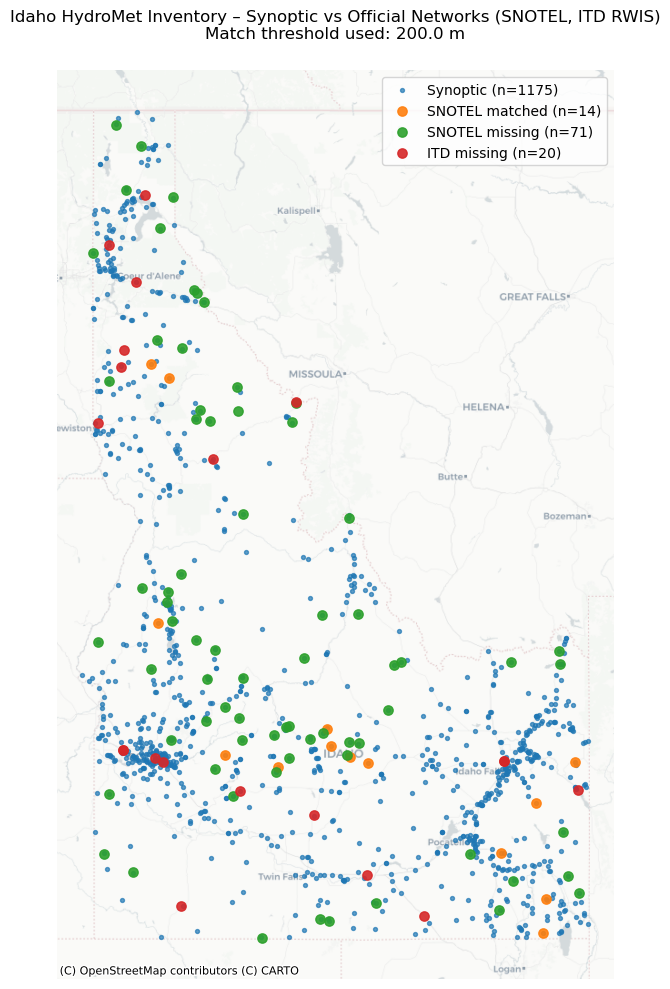

In [11]:
import os, json, requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as cx

# --------------------------
# CONFIG
# --------------------------
OUT_DIR = "out"
STATIONS_ALL_CSV = os.path.join(OUT_DIR, "stations_all.csv")
MATCH_SN_SY_CSV  = os.path.join(OUT_DIR, "matches_snotel_synoptic.csv")
OVERLAP_ITD_CSV  = os.path.join(OUT_DIR, "overlap_synoptic_vs_ITD_Rwis.csv")

MAX_DIST_M = 200.0  # for narrative; ITD overlap already computed with this threshold

# ITD ArcGIS REST query endpoint (from our network_audit notebook)
ITD_RWIS_QUERY = "https://gis.itd.idaho.gov/arcgisprod/rest/services/ArcGISOnline/RoadFeatureLayers/MapServer/6/query"

# --------------------------
# Helpers
# --------------------------
def to_gdf(df, lon_col="longitude", lat_col="latitude"):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=[Point(xy) for xy in zip(df[lon_col], df[lat_col])],
        crs="EPSG:4326"
    )
    return gdf.to_crs(epsg=3857)

def fetch_itd_rwis_points(timeout: int = 60) -> pd.DataFrame:
    """
    Download RWIS point features from ITD ArcGIS REST as GeoJSON.
    """
    params = {
        "where": "1=1",
        "outFields": "*",
        "returnGeometry": "true",
        "f": "geojson",
        "resultRecordCount": 10000,
    }
    r = requests.get(ITD_RWIS_QUERY, params=params, timeout=timeout)
    r.raise_for_status()
    js = r.json()

    feats = js.get("features", [])
    rows = []
    for f in feats:
        geom = f.get("geometry") or {}
        props = f.get("properties") or {}
        coords = geom.get("coordinates")
        lon, lat = (coords[0], coords[1]) if isinstance(coords, list) and len(coords) >= 2 else (None, None)

        rows.append({
            "itd_site_id": props.get("SITEID") or props.get("siteid") or props.get("OBJECTID") or props.get("objectid"),
            "station_name": props.get("SITE") or props.get("site") or props.get("NAME") or props.get("Name"),
            "latitude": pd.to_numeric(lat, errors="coerce"),
            "longitude": pd.to_numeric(lon, errors="coerce"),
        })

    return pd.DataFrame(rows).dropna(subset=["latitude","longitude"]).reset_index(drop=True)

# --------------------------
# Load inputs
# --------------------------
stations_all = pd.read_csv(STATIONS_ALL_CSV)
df_syn = stations_all[stations_all["source"]=="SYNOPTIC"].dropna(subset=["latitude","longitude"]).copy()
df_snotel = stations_all[stations_all["source"]=="SNOTEL"].dropna(subset=["latitude","longitude"]).copy()

m_sn_sy = pd.read_csv(MATCH_SN_SY_CSV)
ov_itd  = pd.read_csv(OVERLAP_ITD_CSV)

# --------------------------
# Split SNOTEL matched vs missing (based on matches file)
# --------------------------
snotel_matched_ids = (
    m_sn_sy["SNOTEL_source_id"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)
df_snotel["source_station_id"] = df_snotel["source_station_id"].astype(str).str.strip()

df_snotel_matched = df_snotel[df_snotel["source_station_id"].isin(snotel_matched_ids)].copy()
df_snotel_missing = df_snotel[~df_snotel["source_station_id"].isin(snotel_matched_ids)].copy()

# --------------------------
# ITD missing (official ITD points minus those matched to Synoptic)
# --------------------------
itd_official = fetch_itd_rwis_points()
itd_official["itd_site_id"] = itd_official["itd_site_id"].astype(str).str.strip()

itd_matched_ids = (
    ov_itd["ITD_site_id"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

itd_missing = itd_official[~itd_official["itd_site_id"].isin(itd_matched_ids)].copy()

# --------------------------
# Make GeoDataFrames
# --------------------------
gdf_syn = to_gdf(df_syn)
gdf_snotel_matched = to_gdf(df_snotel_matched)
gdf_snotel_missing = to_gdf(df_snotel_missing)
gdf_itd_missing = to_gdf(itd_missing)

# --------------------------
# Plot
# --------------------------
fig, ax = plt.subplots(figsize=(8, 10))

gdf_syn.plot(ax=ax, markersize=8, alpha=0.7, label=f"Synoptic (n={len(df_syn)})")
gdf_snotel_matched.plot(ax=ax, markersize=45, alpha=0.9, label=f"SNOTEL matched (n={len(df_snotel_matched)})")
gdf_snotel_missing.plot(ax=ax, markersize=45, alpha=0.9, label=f"SNOTEL missing (n={len(df_snotel_missing)})")
gdf_itd_missing.plot(ax=ax, markersize=45, alpha=0.9, label=f"ITD missing (n={len(itd_missing)})")

# basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
ax.set_title("Idaho HydroMet Inventory – Synoptic vs Official Networks (SNOTEL, ITD RWIS)\n"
             f"Match threshold used: {MAX_DIST_M} m",
             pad=12)

ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()